# Leveraging Poster and Trailer-Audio Embeddings for Cold-Start Movie Recommendation

## Step 1: Load Libraries and Data

In [ ]:
# Load all Libraries
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, Concatenate, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.metrics import MeanAbsoluteError
import pickle

In [ ]:
# Load Datasets

ratings = pd.read_csv("../../../ml-20m/ratings.csv")
movies = pd.read_csv("../../../ml-20m/movies.csv")

print("Ratings shape:", ratings.shape)
print("Movies shape:", movies.shape)

Ratings shape: (20000263, 4)
Movies shape: (27278, 3)


## Step 2: Data Profiling & Preprocessing

In [ ]:
# Inspect the Data

display(ratings.head())
display(movies.head())

print("Ratings Info:\n")
print(ratings.info())
print("\nMovies Info:\n")
print(movies.info())

print("Unique values in Ratings:\n")
print(ratings.nunique())
print("Unique values in Movies:\n")
print(movies.nunique())

,userId,movieId,rating,timestamp
0,1,2,3.5,1112486027
1,1,29,3.5,1112484676
2,1,32,3.5,1112484819
3,1,47,3.5,1112484727
4,1,50,3.5,1112484580


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


Ratings Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000263 entries, 0 to 20000262
Data columns (total 4 columns):
 #   Column     Dtype  
---  ------     -----  
 0   userId     int64  
 1   movieId    int64  
 2   rating     float64
 3   timestamp  int64  
dtypes: float64(1), int64(3)
memory usage: 610.4 MB
None

Movies Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27278 entries, 0 to 27277
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  27278 non-null  int64 
 1   title    27278 non-null  object
 2   genres   27278 non-null  object
dtypes: int64(1), object(2)
memory usage: 639.5+ KB
None
Unique values in Ratings:

userId         138493
movieId         26744
rating             10
timestamp    15351121
dtype: int64
Unique values in Movies:

movieId    27278
title      27262
genres      1342
dtype: int64


In [ ]:
rating_movie_ids = set(ratings["movieId"])
movie_ids = set(movies["movieId"])

missing_movies = rating_movie_ids - movie_ids

print("Movie IDs in ratings:", len(rating_movie_ids))
print("Movie IDs in movies:", len(movie_ids))
print("Missing movie IDs:", len(missing_movies))

Movie IDs in ratings: 26744
Movie IDs in movies: 27278
Missing movie IDs: 0


In [ ]:
clip_folder = "../../../IMG_clip-image"
clip_features = {}

for filename in os.listdir(clip_folder):
    if filename.endswith(".json"):
        path = os.path.join(clip_folder, filename)

        with open(path, "r") as f:
            data = json.load(f)
        for movie_id, embedding in data.items():
            clip_features[int(movie_id)] = embedding
print("CLIP movies:", len(clip_features))

first_movie_id = next(iter(clip_features))
print("Movie ID:", first_movie_id)
print("Embedding length:", len(clip_features[first_movie_id]))

CLIP movies: 25037
Movie ID: 1
Embedding length: 512


In [ ]:
audio_folder = "../../../AUD_vggish/"
audio_features = {}

for filename in os.listdir(audio_folder):
    if filename.endswith(".json"):
        path = os.path.join(audio_folder, filename)
        with open(path, "r") as f:
            data = json.load(f)
        for movie_id, embedding in data.items():
            audio_features[int(movie_id)] = embedding
print("Audio movies:", len(audio_features))

first_movie_id = next(iter(audio_features))
print("Movie ID:", first_movie_id)
print("Embedding length:", len(audio_features[first_movie_id]))

Audio movies: 19340
Movie ID: 1
Embedding length: 128


In [ ]:
movie_ids = set(movies["movieId"])
clip_ids = set(clip_features.keys())
audio_ids = set(audio_features.keys())

multimodal_ids = movie_ids & clip_ids & audio_ids

print("Movies:", len(movie_ids))
print("CLIP:", len(clip_ids))
print("Audio:", len(audio_ids))
print("All three:", len(multimodal_ids))

Movies: 27278
CLIP: 25037
Audio: 19340
All three: 19232


In [ ]:
multimodal_movies = movies[movies["movieId"].isin(multimodal_ids)].copy()
multimodal_movies.shape

(19232, 3)

In [ ]:
multimodal_movies["clip_embedding"] = (multimodal_movies["movieId"].map(clip_features))
multimodal_movies["audio_embedding"] = (multimodal_movies["movieId"].map(audio_features))

multimodal_movies.head()

,movieId,title,genres,clip_embedding,audio_embedding
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[-0.11042045056819916, 0.08279599249362946, 0....","[168.61289978027344, 18.935483932495117, 174.2..."
2,3,Grumpier Old Men (1995),Comedy|Romance,"[0.03343847393989563, -0.17208358645439148, -0...","[161.09677124023438, 17.225805282592773, 162.7..."
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[-0.35217970609664917, 0.13658151030540466, 0....","[166.48387145996094, 9.935483932495117, 178.29..."
4,5,Father of the Bride Part II (1995),Comedy,"[-0.08517539501190186, -0.35294902324676514, -...","[171.5483856201172, 18.612903594970703, 168.64..."
6,7,Sabrina (1995),Comedy|Romance,"[0.34568649530410767, -0.26137441396713257, -0...","[169.09677124023438, 10.967741966247559, 171.0..."


In [ ]:
multimodal_ratings = ratings[ratings["movieId"].isin(multimodal_ids)].copy()

print("Original ratings:", len(ratings))
print("Multimodal ratings:", len(multimodal_ratings))
print("Unique users:", multimodal_ratings["userId"].nunique())
print("Unique movies:", multimodal_ratings["movieId"].nunique())

Original ratings: 20000263
Multimodal ratings: 18788341
Unique users: 138493
Unique movies: 19014


In [ ]:
print ("Final DATASET")

print("Movies:", multimodal_movies["movieId"].nunique())
print("Movies with CLIP:", multimodal_movies["clip_embedding"].notna().sum())
print("Movies with Audio:", multimodal_movies["audio_embedding"].notna().sum())
print("Ratings:", len(multimodal_ratings))
print("Users:", multimodal_ratings["userId"].nunique())

Final DATASET
Movies: 19232
Movies with CLIP: 19232
Movies with Audio: 19232
Ratings: 18788341
Users: 138493


## Step 3: Recommendation Data Analysis

In [ ]:
print("Multimodal ratings shape:", multimodal_ratings.shape)
print("Unique users:", multimodal_ratings["userId"].nunique())
print("Unique movies:", multimodal_ratings["movieId"].nunique())
print("Total ratings:", len(multimodal_ratings))

Multimodal ratings shape: (18788341, 4)
Unique users: 138493
Unique movies: 19014
Total ratings: 18788341


In [ ]:
ratings_per_movie = (multimodal_ratings.groupby("movieId").size())
print(ratings_per_movie.describe())

count    19014.000000
mean       988.131955
std       3564.539009
min          1.000000
25%          6.000000
50%         45.000000
75%        377.000000
max      67310.000000
dtype: float64


In [ ]:
ratings_per_user = (multimodal_ratings.groupby("userId").size())
print(ratings_per_user.describe())

count    138493.000000
mean        135.662748
std         213.070912
min          12.000000
25%          33.000000
50%          64.000000
75%         146.000000
max        7741.000000
dtype: float64


In [ ]:
num_users = multimodal_ratings["userId"].nunique()
num_movies = multimodal_ratings["movieId"].nunique()
num_ratings = len(multimodal_ratings)

possible_interactions = num_users * num_movies
sparsity = 1 - (num_ratings / possible_interactions)

print(f"Possible user-movie interactions: {possible_interactions:,}")
print(f"Observed ratings: {num_ratings:,}")
print(f"Sparsity: {sparsity:.4%}")

Possible user-movie interactions: 2,633,305,902
Observed ratings: 18,788,341
Sparsity: 99.2865%


### Exploratory Data Analysis

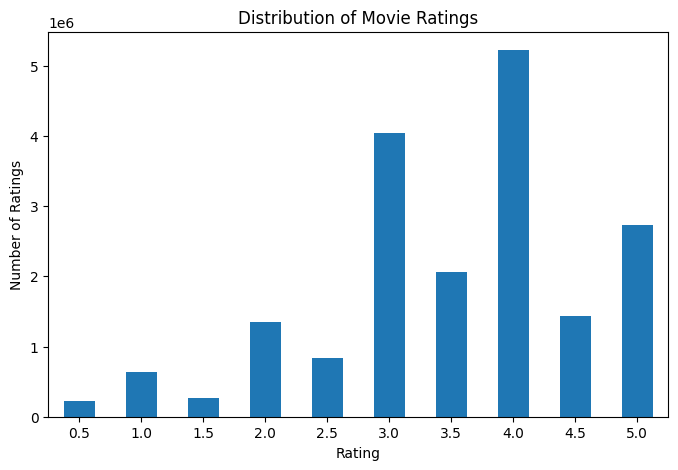

count    1.878834e+07
mean     3.525797e+00
std      1.051049e+00
min      5.000000e-01
25%      3.000000e+00
50%      3.500000e+00
75%      4.000000e+00
max      5.000000e+00
Name: rating, dtype: float64


In [ ]:
rating_counts = multimodal_ratings["rating"].value_counts().sort_index()

plt.figure(figsize=(8, 5))
rating_counts.plot(kind="bar")
plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.xticks(rotation=0)
plt.show()

print(multimodal_ratings["rating"].describe())

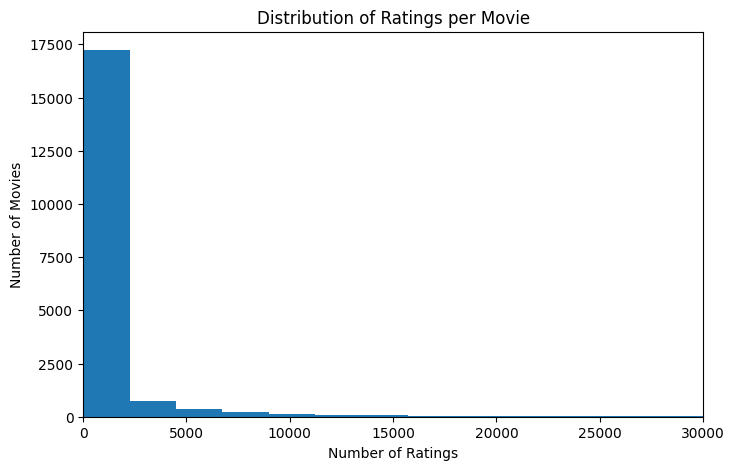

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(ratings_per_movie, bins=30)
plt.title("Distribution of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.xlim(0, 30000)
plt.show()

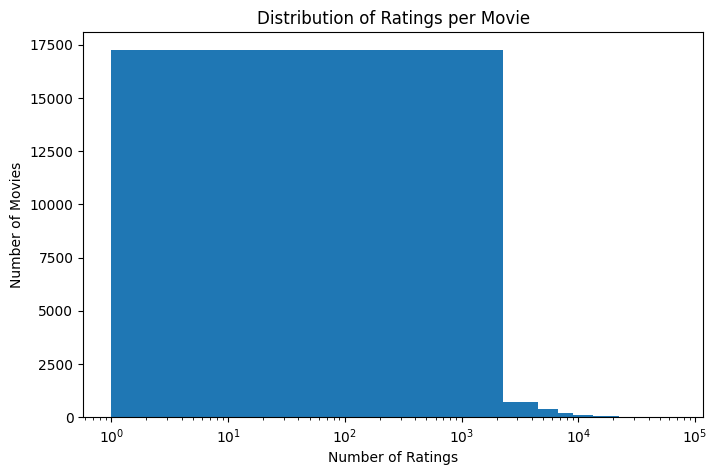

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(ratings_per_movie, bins=30)
plt.title("Distribution of Ratings per Movie")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Movies")
plt.xscale("log")
plt.show()

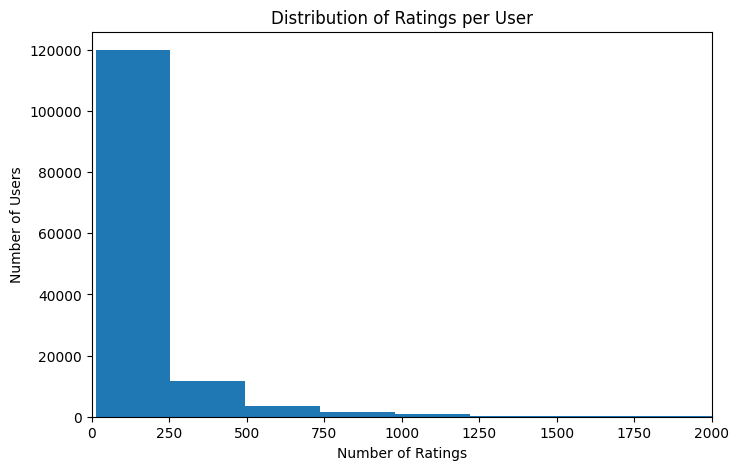

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=32)
plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.xlim(0, 2000)
plt.show()

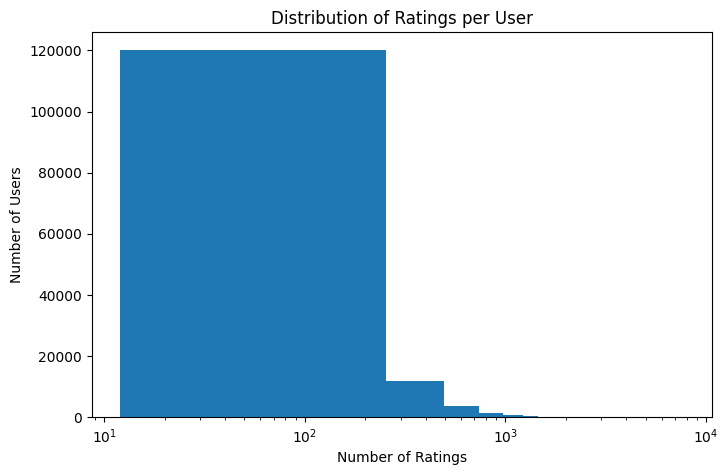

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(ratings_per_user, bins=32)
plt.title("Distribution of Ratings per User")
plt.xlabel("Number of Ratings")
plt.ylabel("Number of Users")
plt.xscale("log")
plt.show()

In [ ]:
top_movies = (multimodal_ratings.groupby("movieId").size().sort_values(ascending=False).head(10))
print(top_movies)

movieId
296     67310
356     66172
318     63366
593     63299
480     59715
260     54502
110     53769
589     52244
2571    51334
527     50054
dtype: int64


In [ ]:
top_movies_df = (top_movies.reset_index(name="rating_count").merge(multimodal_movies[["movieId", "title"]],
                                                                   on="movieId", how="left"))
print(top_movies_df)

   movieId  rating_count                                      title
0      296         67310                        Pulp Fiction (1994)
1      356         66172                        Forrest Gump (1994)
2      318         63366           Shawshank Redemption, The (1994)
3      593         63299           Silence of the Lambs, The (1991)
4      480         59715                       Jurassic Park (1993)
5      260         54502  Star Wars: Episode IV - A New Hope (1977)
6      110         53769                          Braveheart (1995)
7      589         52244          Terminator 2: Judgment Day (1991)
8     2571         51334                         Matrix, The (1999)
9      527         50054                    Schindler's List (1993)


## Step 4: Train-Validation-Test Split

Interactions are split **chronologically per user**, not randomly — a random split could let the model train on future interactions while being tested on past ones, which doesn't reflect real-world recommendation scenarios.

For each user, interactions are ordered by time and split as:

- **Train:** earliest 80%
- **Validation:** next 10%
- **Test:** most recent 10%

This ensures the model learns from past behavior and is evaluated on its ability to predict future preferences — mirroring real deployment conditions. The split is applied **independently per user**, preserving chronological order throughout.

In [ ]:
# Ensure chronological ordering within each user
multimodal_ratings = multimodal_ratings.sort_values(["userId", "timestamp"]).reset_index(drop=True)

train_parts = []
val_parts = []
test_parts = []

for user_id, group in multimodal_ratings.groupby("userId", sort=False):
    n = len(group)
    train_end = int(n * 0.80)
    val_end = int(n * 0.90)

    # Guarantee at least one interaction in every split
    train_end = max(1, train_end)
    val_end = max(train_end + 1, val_end)

    if val_end >= n:
        val_end = n - 1

    train_parts.append(group.iloc[:train_end])
    val_parts.append(group.iloc[train_end:val_end])
    test_parts.append(group.iloc[val_end:])


train_ratings = pd.concat(train_parts, ignore_index=True)
val_ratings = pd.concat(val_parts, ignore_index=True)
test_ratings = pd.concat(test_parts, ignore_index=True)

In [ ]:
print("Train shape:", train_ratings.shape)
print("Validation shape:", val_ratings.shape)
print("Test shape:", test_ratings.shape)

print("\nUnique users:")
print("Train:", train_ratings["userId"].nunique())
print("Validation:", val_ratings["userId"].nunique())
print("Test:", test_ratings["userId"].nunique())

print("\nUnique movies:")
print("Train:", train_ratings["movieId"].nunique())
print("Validation:", val_ratings["movieId"].nunique())
print("Test:", test_ratings["movieId"].nunique())

Train shape: (14975947, 4)
Validation shape: (1871633, 4)
Test shape: (1940761, 4)

Unique users:
Train: 138493
Validation: 138493
Test: 138493

Unique movies:
Train: 16517
Validation: 15763
Test: 17432


In [ ]:
# Check that every user appears in all three splits
train_users = set(train_ratings["userId"])
val_users = set(val_ratings["userId"])
test_users = set(test_ratings["userId"])

print("Users in all three splits:", len(train_users & val_users & test_users))
print("Total users:", multimodal_ratings["userId"].nunique())

Users in all three splits: 138493
Total users: 138493


In [ ]:
# Check chronological ordering
latest_train = train_ratings.groupby("userId")["timestamp"].max()
earliest_val = val_ratings.groupby("userId")["timestamp"].min()
latest_val = val_ratings.groupby("userId")["timestamp"].max()
earliest_test = test_ratings.groupby("userId")["timestamp"].min()

print("Actual Train -> Validation violations:", (latest_train > earliest_val).sum())
print("Actual Validation -> Test violations:", (latest_val > earliest_test).sum())

Actual Train -> Validation violations: 0
Actual Validation -> Test violations: 0


### Exploratory Data Analysis on Train/Val/Test Splits

In [ ]:
# SPLIT STATISTICS
for name, df in [
    ("Train", train_ratings),
    ("Validation", val_ratings),
    ("Test", test_ratings)
]:
    print(f"\n{name}\n")
    print("Rows:", len(df))
    print("Users:", df["userId"].nunique())
    print("Movies:", df["movieId"].nunique())
    print("Mean rating:", round(df["rating"].mean(), 3))
    print("Median rating:", df["rating"].median())


Train

Rows: 14975947
Users: 138493
Movies: 16517
Mean rating: 3.538
Median rating: 4.0

Validation

Rows: 1871633
Users: 138493
Movies: 15763
Mean rating: 3.468
Median rating: 3.5

Test

Rows: 1940761
Users: 138493
Movies: 17432
Mean rating: 3.485
Median rating: 3.5


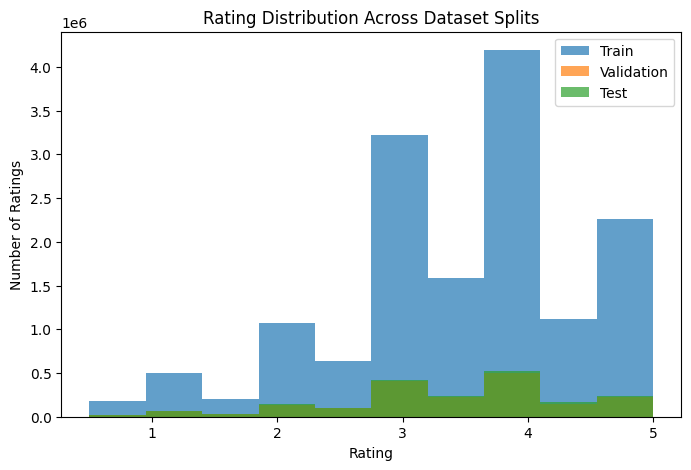

In [ ]:
# Rating distribution across splits
plt.figure(figsize=(8, 5))
plt.hist(train_ratings["rating"], bins=10, alpha=0.7, label="Train")
plt.hist(val_ratings["rating"], bins=10, alpha=0.7, label="Validation")
plt.hist(test_ratings["rating"], bins=10, alpha=0.7, label="Test")
plt.title("Rating Distribution Across Dataset Splits")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")
plt.legend()
plt.show()

In [ ]:
# Movie coverage across splits

train_movies = set(train_ratings["movieId"])
val_movies = set(val_ratings["movieId"])
test_movies = set(test_ratings["movieId"])
val_unseen_movies = val_movies - train_movies
test_unseen_movies = test_movies - train_movies

print("Validation movies unseen in training:", len(val_unseen_movies))
print("Test movies unseen in training:", len(test_unseen_movies))
print("Validation unseen percentage:", round(len(val_unseen_movies) / len(val_movies) * 100, 2), "%")
print("Test unseen percentage:", round(len(test_unseen_movies) / len(test_movies) * 100, 2), "%")

Validation movies unseen in training: 982
Test movies unseen in training: 2107
Validation unseen percentage: 6.23 %
Test unseen percentage: 12.09 %


In [ ]:
# How many ratings does each test movie have in training

train_movie_counts = (train_ratings.groupby("movieId").size().rename("train_rating_count"))
test_movie_analysis = (test_ratings[["movieId"]].drop_duplicates().merge(train_movie_counts,on="movieId",how="left"))
test_movie_analysis["train_rating_count"] = (test_movie_analysis["train_rating_count"].fillna(0))
print(test_movie_analysis["train_rating_count"].describe())

count    17432.000000
mean       858.934201
std       3172.119265
min          0.000000
25%          3.000000
50%         38.500000
75%        313.000000
max      60991.000000
Name: train_rating_count, dtype: float64


In [ ]:
print("Test movies with zero training ratings:", (test_movie_analysis["train_rating_count"] == 0).sum())
print("Test movies with <= 5 training ratings:", (test_movie_analysis["train_rating_count"] <= 5).sum())
print("Test movies with <= 10 training ratings:", (test_movie_analysis["train_rating_count"] <= 10).sum())
print("Test movies with <= 20 training ratings:", (test_movie_analysis["train_rating_count"] <= 20).sum())

Test movies with zero training ratings: 2107
Test movies with <= 5 training ratings: 5177
Test movies with <= 10 training ratings: 6299
Test movies with <= 20 training ratings: 7473


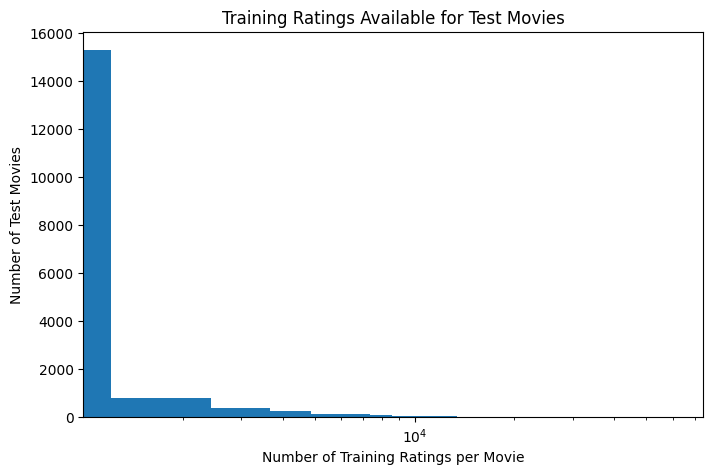

In [ ]:
plt.figure(figsize=(8, 5))
plt.hist(test_movie_analysis["train_rating_count"], bins=50)
plt.title("Training Ratings Available for Test Movies")
plt.xlabel("Number of Training Ratings per Movie")
plt.ylabel("Number of Test Movies")
plt.xscale("log")
plt.show()

In [ ]:
# Summary table showing sparse categories

sparse_summary = pd.DataFrame({
    "Condition": [
        "Zero training ratings",
        "1–5 training ratings",
        "6–10 training ratings",
        "11–20 training ratings",
        "More than 20 training ratings"
    ],
    "Movie Count": [
        (test_movie_analysis["train_rating_count"] == 0).sum(),
        ((test_movie_analysis["train_rating_count"] >= 1) &
         (test_movie_analysis["train_rating_count"] <= 5)).sum(),
        ((test_movie_analysis["train_rating_count"] >= 6) &
         (test_movie_analysis["train_rating_count"] <= 10)).sum(),
        ((test_movie_analysis["train_rating_count"] >= 11) &
         (test_movie_analysis["train_rating_count"] <= 20)).sum(),
        (test_movie_analysis["train_rating_count"] > 20).sum()
    ]
})

sparse_summary["Percentage"] = (sparse_summary["Movie Count"] / len(test_movie_analysis) * 100).round(2)
display(sparse_summary)

,Condition,Movie Count,Percentage
0,Zero training ratings,2107,12.09
1,1–5 training ratings,3070,17.61
2,6–10 training ratings,1122,6.44
3,11–20 training ratings,1174,6.73
4,More than 20 training ratings,9959,57.13


## Step 5: Save Checkpoint Files

**Save all the required files so we don't need to run the entire script again and continue loading what we need**

In [ ]:
checkpoint_dir = "../../../processed_v1"

os.makedirs(checkpoint_dir, exist_ok=True)
print("Checkpoint directory:", checkpoint_dir)

Checkpoint directory: ../../../processed_v1


In [ ]:
train_path = os.path.join(checkpoint_dir, "train_ratings.parquet")
val_path = os.path.join(checkpoint_dir, "val_ratings.parquet")
test_path = os.path.join(checkpoint_dir, "test_ratings.parquet")

train_ratings.to_parquet(train_path, index=False)
val_ratings.to_parquet(val_path, index=False)
test_ratings.to_parquet(test_path, index=False)

print("Saved:")
print(train_path)
print(val_path)
print(test_path)

Saved:
../../../processed_v1\train_ratings.parquet
../../../processed_v1\val_ratings.parquet
../../../processed_v1\test_ratings.parquet


In [ ]:
multimodal_movies_to_save = multimodal_movies[["movieId", "title", "genres"]].copy()
movies_path = os.path.join(checkpoint_dir,"multimodal_movies.parquet")
multimodal_movies_to_save.to_parquet(movies_path, index=False)

print("Saved multimodal movie catalog:", movies_path)
print("Movies:", len(multimodal_movies_to_save))

Saved multimodal movie catalog: ../../../processed_v1\multimodal_movies.parquet
Movies: 19232


In [ ]:
clip_movie_ids = np.array(list(clip_features.keys()), dtype=np.int32)
clip_embeddings = np.asarray(list(clip_features.values()), dtype=np.float32)

print("CLIP movie IDs:", clip_movie_ids.shape)
print("CLIP embeddings:", clip_embeddings.shape)
print("CLIP dtype:", clip_embeddings.dtype)

CLIP movie IDs: (25037,)
CLIP embeddings: (25037, 512)
CLIP dtype: float32


In [ ]:
np.save(os.path.join(checkpoint_dir, "clip_movie_ids.npy"), clip_movie_ids)
np.save(os.path.join(checkpoint_dir, "clip_embeddings.npy"), clip_embeddings)
print("CLIP embeddings saved.")

CLIP embeddings saved.


In [ ]:
vggish_movie_ids = np.array(list(audio_features.keys()), dtype=np.int32)
vggish_embeddings = np.asarray(list(audio_features.values()), dtype=np.float32)

print("VGGish movie IDs:", vggish_movie_ids.shape)
print("VGGish embeddings:", vggish_embeddings.shape)
print("VGGish dtype:", vggish_embeddings.dtype)

VGGish movie IDs: (19340,)
VGGish embeddings: (19340, 128)
VGGish dtype: float32


In [ ]:
np.save(os.path.join(checkpoint_dir, "vggish_movie_ids.npy"), vggish_movie_ids)
np.save(os.path.join(checkpoint_dir, "vggish_embeddings.npy"), vggish_embeddings)

print("VGGish embeddings saved.")

VGGish embeddings saved.


In [ ]:
# saving the metsdata as well

metadata = {
    "project": "Leveraging Poster and Trailer-Audio Embeddings for Cold-Start Movie Recommendation",
    "version": "V1",

    "movielens": {
        "total_ratings_source": int(len(ratings)),
        "users": int(ratings["userId"].nunique()),
        "movies": int(movies["movieId"].nunique())
    },

    "multimodal": {
        "aligned_movies": int(len(multimodal_movies)),
        "movies_with_ratings": int(multimodal_ratings["movieId"].nunique()),
        "movies_without_ratings": int(
            len(multimodal_movies)
            - multimodal_ratings["movieId"].nunique()
        ),
        "clip_movies": int(len(clip_features)),
        "audio_movies": int(len(audio_features)),
        "clip_dimension": int(clip_embeddings.shape[1]),
        "audio_dimension": int(vggish_embeddings.shape[1])
    },

    "interactions": {
        "multimodal_ratings": int(len(multimodal_ratings)),
        "users": int(multimodal_ratings["userId"].nunique()),
        "movies": int(multimodal_ratings["movieId"].nunique())
    },

    "split": {
        "method": "per-user chronological split",
        "train_ratio": 0.80,
        "validation_ratio": 0.10,
        "test_ratio": 0.10,
        "train_rows": int(len(train_ratings)),
        "validation_rows": int(len(val_ratings)),
        "test_rows": int(len(test_ratings))
    }
}

metadata_path = os.path.join(
    checkpoint_dir,
    "dataset_metadata.json"
)

with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=4)

print("Metadata saved:", metadata_path)

Metadata saved: ../../../processed_v1\dataset_metadata.json


In [ ]:
test_movie_analysis_path = os.path.join(checkpoint_dir, "test_movie_sparsity_analysis.parquet")
test_movie_analysis.to_parquet(test_movie_analysis_path, index=False)

print("Saved:", test_movie_analysis_path)

Saved: ../../../processed_v1\test_movie_sparsity_analysis.parquet


In [ ]:
sparse_summary = pd.DataFrame({
    "Condition": [
        "Zero training ratings",
        "1–5 training ratings",
        "6–10 training ratings",
        "11–20 training ratings",
        "More than 20 training ratings"
    ],
    "Movie Count": [
        (test_movie_analysis["train_rating_count"] == 0).sum(),
        ((test_movie_analysis["train_rating_count"] >= 1) &
         (test_movie_analysis["train_rating_count"] <= 5)).sum(),
        ((test_movie_analysis["train_rating_count"] >= 6) &
         (test_movie_analysis["train_rating_count"] <= 10)).sum(),
        ((test_movie_analysis["train_rating_count"] >= 11) &
         (test_movie_analysis["train_rating_count"] <= 20)).sum(),
        (test_movie_analysis["train_rating_count"] > 20).sum()
    ]
})

sparse_summary["Percentage"] = (sparse_summary["Movie Count"] / len(test_movie_analysis) * 100)
display(sparse_summary)

sparse_summary.to_csv(os.path.join(checkpoint_dir, "sparse_feedback_summary.csv"), index=False)
print("Sparse-feedback summary saved.")

,Condition,Movie Count,Percentage
0,Zero training ratings,2107,12.086966
1,1–5 training ratings,3070,17.611290
2,6–10 training ratings,1122,6.436439
3,11–20 training ratings,1174,6.734741
4,More than 20 training ratings,9959,57.130564


Sparse-feedback summary saved.


In [ ]:
print("\n===== CHECKPOINT VERIFICATION =====")

for filename in [
    "train_ratings.parquet",
    "val_ratings.parquet",
    "test_ratings.parquet",
    "multimodal_movies.parquet",
    "clip_embeddings.npy",
    "clip_movie_ids.npy",
    "vggish_embeddings.npy",
    "vggish_movie_ids.npy",
    "dataset_metadata.json",
    "test_movie_sparsity_analysis.parquet",
    "sparse_feedback_summary.csv"
]:
    path = os.path.join(checkpoint_dir, filename)

    if os.path.exists(path):
        size_mb = os.path.getsize(path) / (1024 ** 2)
        print(f"✓ {filename:<40} {size_mb:,.2f} MB")
    else:
        print(f"✗ MISSING: {filename}")


===== CHECKPOINT VERIFICATION =====
✓ train_ratings.parquet                    88.97 MB
✓ val_ratings.parquet                      13.32 MB
✓ test_ratings.parquet                     13.94 MB
✓ multimodal_movies.parquet                0.55 MB
✓ clip_embeddings.npy                      48.90 MB
✓ clip_movie_ids.npy                       0.10 MB
✓ vggish_embeddings.npy                    9.44 MB
✓ vggish_movie_ids.npy                     0.07 MB
✓ dataset_metadata.json                    0.00 MB
✓ test_movie_sparsity_analysis.parquet     0.14 MB
✓ sparse_feedback_summary.csv              0.00 MB


### Reload Verification

In [ ]:
test_train = pd.read_parquet(os.path.join(checkpoint_dir, "train_ratings.parquet"))
test_val = pd.read_parquet(os.path.join(checkpoint_dir, "val_ratings.parquet"))
test_test = pd.read_parquet(os.path.join(checkpoint_dir, "test_ratings.parquet"))

test_clip = np.load(os.path.join(checkpoint_dir, "clip_embeddings.npy"))
test_audio = np.load(os.path.join(checkpoint_dir, "vggish_embeddings.npy"))

print("Train:", test_train.shape)
print("Validation:", test_val.shape)
print("Test:", test_test.shape)
print("CLIP:", test_clip.shape)
print("VGGish:", test_audio.shape)

Train: (14975947, 4)
Validation: (1871633, 4)
Test: (1940761, 4)
CLIP: (25037, 512)
VGGish: (19340, 128)


In [ ]:
test_movies = pd.read_parquet(os.path.join(checkpoint_dir, "multimodal_movies.parquet"))

print("Multimodal movies:", test_movies.shape)
print("Unique movie IDs:", test_movies["movieId"].nunique())

Multimodal movies: (19232, 3)
Unique movie IDs: 19232


## Step 6: Baseline Models

In [3]:
# Load all the data from checkpoint directory

import os
import json
import numpy as np
import pandas as pd

checkpoint_dir = "../../../processed_v1"
train_ratings = pd.read_parquet(os.path.join(checkpoint_dir, "train_ratings.parquet"))
val_ratings = pd.read_parquet(os.path.join(checkpoint_dir, "val_ratings.parquet"))
test_ratings = pd.read_parquet(os.path.join(checkpoint_dir, "test_ratings.parquet"))

multimodal_movies = pd.read_parquet(os.path.join(checkpoint_dir, "multimodal_movies.parquet"))

clip_movie_ids = np.load(os.path.join(checkpoint_dir, "clip_movie_ids.npy"))
clip_embeddings = np.load(os.path.join(checkpoint_dir, "clip_embeddings.npy"))

vggish_movie_ids = np.load(os.path.join(checkpoint_dir, "vggish_movie_ids.npy"))
vggish_embeddings = np.load(os.path.join(checkpoint_dir, "vggish_embeddings.npy"))

with open(os.path.join(checkpoint_dir, "dataset_metadata.json"), "r") as f:
    dataset_metadata = json.load(f)

print("All V1 checkpoint data loaded successfully.")

All V1 checkpoint data loaded successfully.


In [4]:
# check size of the loaded data
print("Train ratings shape:", train_ratings.shape)
print("Validation ratings shape:", val_ratings.shape)
print("Test ratings shape:", test_ratings.shape)
print("Multimodal movies shape:", multimodal_movies.shape)
print("CLIP embeddings shape:", clip_embeddings.shape)
print("VGGish embeddings shape:", vggish_embeddings.shape)

Train ratings shape: (14975947, 4)
Validation ratings shape: (1871633, 4)
Test ratings shape: (1940761, 4)
Multimodal movies shape: (19232, 3)
CLIP embeddings shape: (25037, 512)
VGGish embeddings shape: (19340, 128)


In [5]:
# Store results

results = []
def add_result(
    model_name,
    val_mae,
    val_rmse,
    test_mae,
    test_rmse,
    notes=""
):
    results.append({
        "Model": model_name,
        "Validation MAE": val_mae,
        "Validation RMSE": val_rmse,
        "Test MAE": test_mae,
        "Test RMSE": test_rmse,
        "Notes": notes
    })

    return pd.DataFrame(results)

### 6.1 Baseline 1 - Global Mean

In [6]:
# Calculate Global mean rating
global_mean = train_ratings["rating"].mean()
print(f"Global mean rating: {global_mean:.4f}")

Global mean rating: 3.5382


In [7]:
# Evaluate Global Mean Baseline
val_pred_mean = np.full(len(val_ratings), global_mean)
test_pred_mean = np.full(len(test_ratings), global_mean)

In [8]:
# Compute evaluation metrics for the global mean baseline
val_mae_global = mean_absolute_error(val_ratings["rating"], val_pred_mean)
val_rmse_global = np.sqrt(mean_squared_error(val_ratings["rating"], val_pred_mean))
val_r2_global = r2_score(val_ratings["rating"], val_pred_mean)
test_mae_global = mean_absolute_error(test_ratings["rating"],test_pred_mean)
test_rmse_global = np.sqrt(mean_squared_error(test_ratings["rating"], test_pred_mean))
test_r2_global = r2_score(test_ratings["rating"], test_pred_mean)

print("Global Mean Baseline")
print(f"Validation MAE:  {val_mae_global:.4f}")
print(f"Validation RMSE: {val_rmse_global:.4f}")
print(f"Validation R²: {val_r2_global:.4f}")
print(f"Test MAE:        {test_mae_global:.4f}")
print(f"Test RMSE:       {test_rmse_global:.4f}")
print(f"Test R²:       {test_r2_global:.4f}")

Global Mean Baseline
Validation MAE:  0.8228
Validation RMSE: 1.0399
Validation R²: -0.0045
Test MAE:        0.8267
Test RMSE:       1.0445
Test R²:       -0.0026


In [9]:
add_result(
    "Global Mean",
    val_mae_global,
    val_rmse_global,
    test_mae_global,
    test_rmse_global,
    "Simple reference baseline"
)

,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE,Notes
0,Global Mean,0.822776,1.039851,0.826679,1.044473,Simple reference baseline


This concludes that there are no very large value errors in ratings

### 6.2 Baseline 2 - User + Movie Bias

The global mean baseline does not account for systematic differences between users or movies. A stronger non-neural baseline is therefore constructed using **user and movie biases**:
$$
\hat{r}_{ui} = \mu + b_u + b_i
$$
**Where:**

 $\mu$  The global mean rating across all training data
 $b_u$  The tendency of user $u$ to rate above or below the global mean
 $b_i$  The tendency of movie $i$ to receive ratings above or below the global mean

**Notes:**

- The biases $b_u$ and $b_i$ are estimated **exclusively from the training data**, to prevent information leakage into the validation and test sets.

In [10]:
# Global mean from training data
global_mean = train_ratings["rating"].mean()

# User bias
user_stats = (train_ratings.groupby("userId")["rating"].agg(["mean", "count"]))
user_bias = user_stats["mean"] - global_mean

# Movie bias
movie_stats = (train_ratings.groupby("movieId")["rating"].agg(["mean", "count"]))
movie_bias = movie_stats["mean"] - global_mean

print(f"Global mean: {global_mean:.4f}")
print(f"Users with learned bias: {len(user_bias):,}")
print(f"Movies with learned bias: {len(movie_bias):,}")

Global mean: 3.5382
Users with learned bias: 138,493
Movies with learned bias: 16,517


In [11]:
# Prediction function for the user + movie bias model
def predict_bias_model(df):
    predictions = (
        global_mean
        + df["userId"].map(user_bias).fillna(0)
        + df["movieId"].map(movie_bias).fillna(0)
    )
    # Keep predictions within the valid MovieLens rating range
    return predictions.clip(0.5, 5.0)

In [12]:
# Evaluate the user + movie bias model on validation and test sets
val_pred_bias = predict_bias_model(val_ratings)
test_pred_bias = predict_bias_model(test_ratings)

In [13]:
# Compute evaluation metrics for the user + movie bias model
val_mae_bias = mean_absolute_error(val_ratings["rating"], val_pred_bias)
val_rmse_bias = np.sqrt(mean_squared_error(val_ratings["rating"], val_pred_bias))
val_r2_bias = r2_score(val_ratings["rating"], val_pred_bias)
test_mae_bias = mean_absolute_error(test_ratings["rating"], test_pred_bias)
test_rmse_bias = np.sqrt(mean_squared_error(test_ratings["rating"], test_pred_bias))
test_r2_bias = r2_score(test_ratings["rating"], test_pred_bias)

print("User + Movie Bias Baseline")
print(f"Validation MAE:  {val_mae_bias:.4f}")
print(f"Validation RMSE: {val_rmse_bias:.4f}")
print(f"Validation R²: {val_r2_bias:.4f}")
print(f"Test MAE:        {test_mae_bias:.4f}")
print(f"Test RMSE:       {test_rmse_bias:.4f}")
print(f"Test R²:       {test_r2_bias:.4f}")

User + Movie Bias Baseline
Validation MAE:  0.6665
Validation RMSE: 0.8741
Validation R²: 0.2902
Test MAE:        0.6799
Test RMSE:       0.8926
Test R²:       0.2678


In [14]:
add_result(
    "User + Movie Bias",
    val_mae_bias,
    val_rmse_bias,
    test_mae_bias,
    test_rmse_bias,
    "Classical collaborative baseline"
)

,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE,Notes
0,Global Mean,0.822776,1.039851,0.826679,1.044473,Simple reference baseline
1,User + Movie Bias,0.666467,0.874104,0.679932,0.892608,Classical collaborative baseline


### 6.3 Baseline 3 - Neural Collaborative Filtering

This model predicts a user's rating for a movie using:

- User embedding
- Movie embedding
- Concatenated latent representation
- Fully connected neural network layers


In [15]:
# Create 1D mappings using training data only
user_ids = train_ratings["userId"].unique()
movie_ids = train_ratings["movieId"].unique()

user_to_index = {user_id: idx for idx, user_id in enumerate(user_ids)}
movie_to_index = {movie_id: idx for idx, movie_id in enumerate(movie_ids)}

num_users = len(user_to_index)
num_movies = len(movie_to_index)

print(f"Users in training:  {num_users:,}")
print(f"Movies in training: {num_movies:,}")

Users in training:  138,493
Movies in training: 16,517


In [16]:
# Convert interactions to embedding indices
def prepare_ncf_data(df):
    data = df.copy()
    data["user_idx"] = data["userId"].map(user_to_index)
    data["movie_idx"] = data["movieId"].map(movie_to_index)
    return data

In [17]:
train_ncf = prepare_ncf_data(train_ratings)
print(train_ncf[["userId", "movieId", "user_idx", "movie_idx", "rating"]].head())

   userId  movieId  user_idx  movie_idx  rating
0       1      924         0          0     3.5
1       1      919         0          1     3.5
2       1     2683         0          2     3.5
3       1     1584         0          3     3.5
4       1     1079         0          4     4.0


In [18]:
# Prepare validation and test data for NCF model
val_ncf = prepare_ncf_data(val_ratings)
test_ncf = prepare_ncf_data(test_ratings)

print("Validation interactions:", len(val_ncf))
print("Validation unseen movies:", val_ncf["movie_idx"].isna().sum())
print("Test interactions:", len(test_ncf))
print("Test unseen movies:", test_ncf["movie_idx"].isna().sum())

Validation interactions: 1871633
Validation unseen movies: 1310
Test interactions: 1940761
Test unseen movies: 3630


In [19]:
# Create NCF model

def build_ncf_model(num_users, num_movies, embedding_dim=32):
    user_input = Input(shape=(1,))
    movie_input = Input(shape=(1,))
    user_embedding = Embedding(num_users, embedding_dim)(user_input)
    movie_embedding = Embedding(num_movies, embedding_dim)(movie_input)
    x = Concatenate()([user_embedding, movie_embedding])
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation="relu")(x)
    output = Dense(1)(x)
    return keras.Model([user_input, movie_input], output)

In [20]:
# Build and compile the NCF model

ncf_model = build_ncf_model(num_users, num_movies, embedding_dim=32)

ncf_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

ncf_model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_1       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 1, 32)     │  4,431,776 │ input_layer[0][0] │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_1         │ (None, 1, 32)     │    528,544 │ input_layer_1[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate         │ (None, 1, 64)     │          0 │ embedding[0][0],  │
│ (Concatenate)       │                   │            │ embedding_1[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 1, 64)     │      4,160 │ concatenate[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 1, 64)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 1, 32)     │      2,080 │ dropout[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 1, 1)      │         33 │ dense_1[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,966,593 (18.95 MB)

 Trainable params: 4,966,593 (18.95 MB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# Preparation of Train, Validation and Test Data for NCF Model
train_users = train_ncf["user_idx"].astype("int32").to_numpy()
train_movies = train_ncf["movie_idx"].astype("int32").to_numpy()
train_targets = train_ncf["rating"].astype("float32").to_numpy()

print("Training users:", train_users.shape)
print("Training movies:", train_movies.shape)
print("Training targets:", train_targets.shape)

print("\nTarget statistics:")
print(f"Mean: {train_targets.mean():.4f}")
print(f"Min:  {train_targets.min():.1f}")
print(f"Max:  {train_targets.max():.1f}")

val_ncf_seen = val_ncf.dropna(subset=["movie_idx"]).copy()
val_users = val_ncf_seen["user_idx"].astype("int32").to_numpy()
val_movies = val_ncf_seen["movie_idx"].astype("int32").to_numpy()
val_targets = val_ncf_seen["rating"].astype("float32").to_numpy()

print("\nValidation interactions with seen movies:", len(val_ncf_seen))
print("Validation interactions excluded:", len(val_ncf) - len(val_ncf_seen))

test_ncf_seen = test_ncf.dropna(subset=["movie_idx"]).copy()
test_users = test_ncf_seen["user_idx"].astype("int32").to_numpy()
test_movies = test_ncf_seen["movie_idx"].astype("int32").to_numpy()
test_targets = test_ncf_seen["rating"].astype("float32").to_numpy()

print("\nTest interactions with seen movies:", len(test_ncf_seen))
print("Test interactions excluded:", len(test_ncf) - len(test_ncf_seen))

Training users: (14975947,)
Training movies: (14975947,)
Training targets: (14975947,)

Target statistics:
Mean: 3.5382
Min:  0.5
Max:  5.0

Validation interactions with seen movies: 1870323
Validation interactions excluded: 1310

Test interactions with seen movies: 1937131
Test interactions excluded: 3630


In [22]:
# Callbacks for NCF model training

model_dir = os.path.join(checkpoint_dir, "")
os.makedirs(model_dir, exist_ok=True)

callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=2,
        min_lr=1e-5,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=os.path.join(model_dir, "ncf_best.keras"),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
]

In [23]:
# Train the NCF model
history = ncf_model.fit(
    x=[train_users, train_movies],
    y=train_targets,
    validation_data=(
        [val_users, val_movies],
        val_targets
    ),
    epochs=10,
    batch_size=1024,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/10
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.3571 - mae: 0.9068
Epoch 1: val_loss improved from None to 1.07980, saving model to /content/ncf_best.keras

Epoch 1: finished saving model to /content/ncf_best.keras
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 63s 4ms/step - loss: 1.1510 - mae: 0.8557 - val_loss: 1.0798 - val_mae: 0.8221 - learning_rate: 0.0010
Epoch 2/10
14623/14625 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1096 - mae: 0.8443
Epoch 2: val_loss did not improve from 1.07980
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 63s 4ms/step - loss: 1.1098 - mae: 0.8444 - val_loss: 1.0836 - val_mae: 0.8237 - learning_rate: 0.0010
Epoch 3/10
14618/14625 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1094 - mae: 0.8442
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 3: val_loss did not improve from 1.07980
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 57s 4ms/step - loss: 1.1098 - mae: 0.8444 - val_loss: 1.0837 - val_mae: 0.8238 - learning_rate: 0.0010
Epoch 4/10
14621/1

In [24]:
# NCF predictions on the seen-movie test set
test_pred_ncf = ncf_model.predict(
    [test_users, test_movies],
    batch_size=4096,
    verbose=1
).ravel()

# Keep predictions within rating range
test_pred_ncf = np.clip(test_pred_ncf, 0.5, 5.0)
ncf_test_mae = mean_absolute_error(test_targets, test_pred_ncf)
ncf_test_rmse = np.sqrt(mean_squared_error(test_targets, test_pred_ncf))

print("NCF Test Performance")
print(f"Test MAE:  {ncf_test_mae:.4f}")
print(f"Test RMSE: {ncf_test_rmse:.4f}")

473/473 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
NCF Test Performance
Test MAE:  0.8262
Test RMSE: 1.0438


In [25]:
val_pred_ncf = ncf_model.predict(
    [val_users, val_movies],
    batch_size=4096,
    verbose=1
).ravel()

val_pred_ncf = np.clip(val_pred_ncf, 0.5, 5.0)
ncf_val_mae = mean_absolute_error(val_targets, val_pred_ncf)
ncf_val_rmse = np.sqrt(mean_squared_error(val_targets, val_pred_ncf))

print("NCF Validation Performance")
print("-" * 35)
print(f"Validation MAE:  {ncf_val_mae:.4f}")
print(f"Validation RMSE: {ncf_val_rmse:.4f}")

457/457 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
NCF Validation Performance
-----------------------------------
Validation MAE:  0.8221
Validation RMSE: 1.0391


In [26]:
add_result(
    "NCF",
    ncf_val_mae,
    ncf_val_rmse,
    ncf_test_mae,
    ncf_test_rmse,
    "Neural collaborative filtering"
)

,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE,Notes
0,Global Mean,0.822776,1.039851,0.826679,1.044473,Simple reference baseline
1,User + Movie Bias,0.666467,0.874104,0.679932,0.892608,Classical collaborative baseline
2,NCF,0.822106,1.039123,0.826192,1.043829,Neural collaborative filtering


NCF did not outperform the User + Movie Bias baseline, indicating that the basic neural embedding architecture did not provide an advantage over the strong bias-based collaborative baseline for rating prediction.

## Step 7: Multimodal Model

In [27]:
# Load saved multimodal embeddings

clip_embeddings = np.load(os.path.join(checkpoint_dir, "clip_embeddings.npy"))
clip_movie_ids = np.load(os.path.join(checkpoint_dir, "clip_movie_ids.npy"))
audio_embeddings = np.load(os.path.join(checkpoint_dir, "vggish_embeddings.npy"))
audio_movie_ids = np.load(os.path.join(checkpoint_dir, "vggish_movie_ids.npy"))

print("CLIP embeddings:", clip_embeddings.shape)
print("CLIP movie IDs:", clip_movie_ids.shape)
print("VGGish embeddings:", audio_embeddings.shape)
print("VGGish movie IDs:", audio_movie_ids.shape)

CLIP embeddings: (25037, 512)
CLIP movie IDs: (25037,)
VGGish embeddings: (19340, 128)
VGGish movie IDs: (19340,)


In [28]:
# Create movie -> embeddings index mappings

clip_index = {
    int(movie_id): idx
    for idx, movie_id in enumerate(clip_movie_ids)
}

audio_index = {
    int(movie_id): idx
    for idx, movie_id in enumerate(audio_movie_ids)
}

print("CLIP index:", len(clip_index))
print("Audio index:", len(audio_index))

CLIP index: 25037
Audio index: 19340


### Step 7.1: Aligned Multimodal Movie Features

In [29]:
# Create aligned movie IDs
aligned_movie_ids = sorted(set(clip_index.keys()) & set(audio_index.keys()))

print("Movies with both modalities:", len(aligned_movie_ids))

Movies with both modalities: 19232


In [30]:
aligned_clip = np.stack([clip_embeddings[clip_index[movie_id]]
    for movie_id in aligned_movie_ids]).astype("float32")

aligned_audio = np.stack([audio_embeddings[audio_index[movie_id]]
    for movie_id in aligned_movie_ids]).astype("float32")

print("Aligned CLIP:", aligned_clip.shape)
print("Aligned Audio:", aligned_audio.shape)

Aligned CLIP: (19232, 512)
Aligned Audio: (19232, 128)


In [31]:
# Lookup index
multimodal_movie_index = {
    movie_id: idx
    for idx, movie_id in enumerate(aligned_movie_ids)
}

In [32]:
# Ensure original and Multimodal training interactions are same
train_mm = train_ratings[train_ratings["movieId"].isin(multimodal_movie_index)].copy()

print("Original training interactions:", len(train_ratings))
print("Multimodal training interactions:", len(train_mm))
print("Coverage:", f"{len(train_mm) / len(train_ratings) * 100:.2f}%")

train_mm["mm_movie_idx"] = train_mm["movieId"].map(multimodal_movie_index)
print("Missing multimodal indices:", train_mm["mm_movie_idx"].isna().sum())

Original training interactions: 14975947
Multimodal training interactions: 14975947
Coverage: 100.00%
Missing multimodal indices: 0


In [33]:
# Prepare the multimodal training arrays

train_mm_users = train_mm["userId"].map(user_to_index).astype("int32").to_numpy()
train_mm_movies = train_mm["movieId"].map(movie_to_index).astype("int32").to_numpy()
train_mm_content = train_mm["movieId"].map(multimodal_movie_index).astype("int32").to_numpy()
train_mm_targets = train_mm["rating"].astype("float32").to_numpy()

print("Users:", train_mm_users.shape)
print("Movie IDs:", train_mm_movies.shape)
print("Content IDs:", train_mm_content.shape)
print("Targets:", train_mm_targets.shape)

Users: (14975947,)
Movie IDs: (14975947,)
Content IDs: (14975947,)
Targets: (14975947,)


In [34]:
# Check Range of all training features
print("Users:", train_mm_users.min(), train_mm_users.max())
print("Movies:", train_mm_movies.min(), train_mm_movies.max())
print("Content:", train_mm_content.min(), train_mm_content.max())
print("Ratings:", train_mm_targets.min(), train_mm_targets.max())

Users: 0 138492
Movies: 0 16516
Content: 0 19229
Ratings: 0.5 5.0


### Step 7.2: Multimodal Neural Recommender

In [35]:
def build_multimodal_recommender(num_users, num_movies, clip_dim=512, audio_dim=128, embedding_dim=32):

    user_input = keras.Input(shape=(1,), dtype="int32")
    movie_input = keras.Input(shape=(1,), dtype="int32")
    clip_input = keras.Input(shape=(clip_dim,), dtype="float32")
    audio_input = keras.Input(shape=(audio_dim,), dtype="float32")

    user_emb = Embedding(num_users, embedding_dim)(user_input)
    movie_emb = Embedding(num_movies, embedding_dim)(movie_input)

    user_emb = Flatten()(user_emb)
    movie_emb = Flatten()(movie_emb)

    clip_emb = Dense(embedding_dim, activation="relu")(clip_input)
    audio_emb = Dense(embedding_dim, activation="relu")(audio_input)

    x = Concatenate()([user_emb, movie_emb, clip_emb, audio_emb])
    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation="relu")(x)

    output = Dense(1)(x)

    return keras.Model(
        inputs=[user_input, movie_input, clip_input, audio_input],
        outputs=output
    )

In [36]:
multimodal_model = build_multimodal_recommender(
    num_users=num_users,
    num_movies=num_movies,
    embedding_dim=32
)

multimodal_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="mse",
    metrics=[MeanAbsoluteError(name="mae")]
)

### Step 7.3: Memory-Efficient Batch Training

Because the training dataset contains approximately 15 million interactions, expanding movie-level multimodal embeddings to interaction-level arrays would require excessive memory.

A batch-wise input pipeline is therefore used. Movie content embeddings are retrieved only for the current training batch, allowing the original compact embedding matrices to remain in memory without creating large duplicated arrays.

In [37]:
BATCH_SIZE = 1024

train_users = train_mm["userId"].map(user_to_index).astype("int32").to_numpy()
train_movies = train_mm["movieId"].map(movie_to_index).astype("int32").to_numpy()
train_content = train_mm["movieId"].map(multimodal_movie_index).astype("int32").to_numpy()
train_targets = train_mm["rating"].astype("float32").to_numpy()

print("Users:", train_users.shape)
print("Movies:", train_movies.shape)
print("Content indices:", train_content.shape)
print("Targets:", train_targets.shape)

Users: (14975947,)
Movies: (14975947,)
Content indices: (14975947,)
Targets: (14975947,)


In [38]:
# Create batch Generator for multimodal training
def multimodal_batch_generator(users, movies, content_indices, targets, batch_size=1024,shuffle=True):
    n = len(targets)
    indices = np.arange(n)
    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, n, batch_size):
        batch_idx = indices[start:start + batch_size]
        batch_users = users[batch_idx]
        batch_movies = movies[batch_idx]
        batch_content = content_indices[batch_idx]
        batch_targets = targets[batch_idx]
        batch_clip = aligned_clip[batch_content]
        batch_audio = aligned_audio[batch_content]
        yield ((batch_users,
                batch_movies,
                batch_clip,
                batch_audio), batch_targets)

In [39]:
# Create TensorFlow Dataset
output_signature = (
    (
        tf.TensorSpec(shape=(None,), dtype=tf.int32),
        tf.TensorSpec(shape=(None,), dtype=tf.int32),
        tf.TensorSpec(shape=(None, 512), dtype=tf.float32),
        tf.TensorSpec(shape=(None, 128), dtype=tf.float32)
    ),
    tf.TensorSpec(shape=(None,), dtype=tf.float32)
)

train_dataset = tf.data.Dataset.from_generator(
    lambda: multimodal_batch_generator(
        train_users,
        train_movies,
        train_content,
        train_targets,
        batch_size=BATCH_SIZE,
        shuffle=True
    ),
    output_signature=output_signature
)

train_dataset = train_dataset.repeat().prefetch(tf.data.AUTOTUNE)

In [40]:
# Verify the dataset by fetching a single batch
sample_inputs, sample_targets = next(iter(train_dataset))
sample_users, sample_movies, sample_clip, sample_audio = sample_inputs

print("Users:", sample_users.shape)
print("Movies:", sample_movies.shape)
print("CLIP:", sample_clip.shape)
print("Audio:", sample_audio.shape)
print("Targets:", sample_targets.shape)

Users: (1024,)
Movies: (1024,)
CLIP: (1024, 512)
Audio: (1024, 128)
Targets: (1024,)


In [41]:
# Create Callbacks for Training
multimodal_callbacks = [
    EarlyStopping(
        monitor="val_loss",
        patience=2,
        mode="min",
        restore_best_weights=True,
        verbose=1
    ),

    ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-5,
        verbose=1
    ),

    ModelCheckpoint(
        filepath=os.path.join(
            model_dir,
            "multimodal_best.keras"
        ),
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )
]

In [42]:
# Prepare validation data
val_mm = val_ratings[val_ratings["movieId"].isin(multimodal_movie_index)].copy()

val_mm["mm_movie_idx"] = val_mm["movieId"].map(multimodal_movie_index)
val_mm["user_idx"] = val_mm["userId"].map(user_to_index)
val_mm["movie_idx"] = val_mm["movieId"].map(movie_to_index)

print("Validation interactions:", len(val_mm))
print("Missing content indices:", val_mm["mm_movie_idx"].isna().sum())

Validation interactions: 1871633
Missing content indices: 0


In [43]:
# Prepare validation arrays
val_mm = val_mm.dropna(subset=["user_idx", "movie_idx", "mm_movie_idx"]).copy()

val_mm_users = val_mm["user_idx"].astype("int32").to_numpy()
val_mm_movies = val_mm["movie_idx"].astype("int32").to_numpy()
val_mm_content = val_mm["mm_movie_idx"].astype("int32").to_numpy()
val_mm_targets = val_mm["rating"].astype("float32").to_numpy()

In [44]:
# Create TensorFlow Dataset
val_dataset = tf.data.Dataset.from_generator(
    lambda: multimodal_batch_generator(
        val_mm_users,
        val_mm_movies,
        val_mm_content,
        val_mm_targets,
        batch_size=BATCH_SIZE,
        shuffle=False
    ),
    output_signature=output_signature
)

val_dataset = val_dataset.repeat().prefetch(tf.data.AUTOTUNE)

In [45]:
history_mm = multimodal_model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=15,
    steps_per_epoch=int(np.ceil(
        len(train_targets) / BATCH_SIZE
    )),
    validation_steps=int(np.ceil(
        len(val_mm_targets) / BATCH_SIZE
    )),
    callbacks=multimodal_callbacks,
    verbose=1
)

Epoch 1/15
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 7.4104 - mae: 1.1133
Epoch 1: val_loss improved from None to 0.90975, saving model to /content/multimodal_best.keras

Epoch 1: finished saving model to /content/multimodal_best.keras
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 102s 7ms/step - loss: 1.6827 - mae: 0.7646 - val_loss: 0.9098 - val_mae: 0.7780 - learning_rate: 0.0010
Epoch 2/15
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7391 - mae: 0.6616
Epoch 2: val_loss improved from 0.90975 to 0.85658, saving model to /content/multimodal_best.keras

Epoch 2: finished saving model to /content/multimodal_best.keras
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 88s 6ms/step - loss: 0.7360 - mae: 0.6600 - val_loss: 0.8566 - val_mae: 0.7504 - learning_rate: 0.0010
Epoch 3/15
14620/14625 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.7124 - mae: 0.6481
Epoch 3: val_loss improved from 0.85658 to 0.79182, saving model to /content/multimodal_best.keras

Epoch 3: finished saving model to /content/mu

In [46]:
# Prepare test data
test_mm = test_ratings[
    test_ratings["movieId"].isin(multimodal_movie_index) &
    test_ratings["userId"].isin(user_to_index) &
    test_ratings["movieId"].isin(movie_to_index)
].copy()

test_mm["mm_movie_idx"] = test_mm["movieId"].map(multimodal_movie_index)
test_mm["user_idx"] = test_mm["userId"].map(user_to_index)
test_mm["movie_idx"] = test_mm["movieId"].map(movie_to_index)

In [47]:
# Prepare test arrays
test_mm_users = test_mm["user_idx"].astype("int32").to_numpy()
test_mm_movies = test_mm["movie_idx"].astype("int32").to_numpy()
test_mm_content = test_mm["mm_movie_idx"].astype("int32").to_numpy()
test_mm_targets = test_mm["rating"].astype("float32").to_numpy()

In [48]:
# Create test dataset
test_dataset = tf.data.Dataset.from_generator(
    lambda: multimodal_batch_generator(
        test_mm_users,
        test_mm_movies,
        test_mm_content,
        test_mm_targets,
        batch_size=BATCH_SIZE,
        shuffle=False
    ),
    output_signature=output_signature
).prefetch(tf.data.AUTOTUNE)

In [81]:
# Evaluate The Multimodal model
test_results = multimodal_model.evaluate(
    test_dataset,
    steps=int(np.ceil(
        len(test_mm_targets) / BATCH_SIZE
    )),
    verbose=1
)

mm_test_loss = test_results[0]
mm_test_mae = test_results[1]
mm_test_rmse = np.sqrt(mm_test_loss)

print("Multimodal Test Loss:", mm_test_loss)
print("Multimodal Test MAE:", mm_test_mae)
print("Multimodal Test RMSE:", mm_test_rmse)

1892/1892 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.7264 - mae: 0.6622
Multimodal Test Loss: 0.7263972759246826
Multimodal Test MAE: 0.662196159362793
Multimodal Test RMSE: 0.8522894320151357


In [85]:
mm_val_mae = history_mm.history["val_mae"][-1]
mm_val_rmse = np.sqrt(history_mm.history["val_loss"][-1])

add_result(
    "MM",
    mm_val_mae,
    mm_val_rmse,
    mm_test_mae,
    mm_test_rmse,
    "Multimodal Model"
)

,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE,Notes
0,Global Mean,0.822776,1.039851,0.826679,1.044473,Simple reference baseline
1,User + Movie Bias,0.666467,0.874104,0.679932,0.892608,Classical collaborative baseline
2,NCF,0.822106,1.039123,0.826192,1.043829,Neural collaborative filtering
3,MM,0.656400,0.838690,0.662196,0.852289,Multimodal Model


## Step 8: Seen vs. Unseen Movie Evaluation

To evaluate cold-start performance, test interactions are divided into seen and unseen movie groups based on whether the movie received any interaction in the training set.

In [57]:
# Identify movies seen during training
train_movie_set = set(train_ratings["movieId"].unique())

# Create seen/unseen flags on the ORIGINAL test set
test_ratings_analysis = test_ratings.copy()
test_ratings_analysis["is_unseen_movie"] = (~test_ratings_analysis["movieId"].isin(train_movie_set))

# Summary
print("Test interactions:", len(test_ratings_analysis))
print("Seen interactions:", (~test_ratings_analysis["is_unseen_movie"]).sum())
print("Unseen interactions:", test_ratings_analysis["is_unseen_movie"].sum())
print("\nSeen movies:", test_ratings_analysis.loc[~test_ratings_analysis["is_unseen_movie"], "movieId"].nunique())
print("Unseen movies:", test_ratings_analysis.loc[test_ratings_analysis["is_unseen_movie"], "movieId"].nunique())

Test interactions: 1940761
Seen interactions: 1937131
Unseen interactions: 3630

Seen movies: 15325
Unseen movies: 2107


In [58]:
unseen_test_movies = set(test_ratings_analysis.loc[test_ratings_analysis["is_unseen_movie"], "movieId"])
unseen_with_both_modalities = unseen_test_movies & set(multimodal_movie_index.keys())

print("Unseen test movies:", len(unseen_test_movies))
print("Unseen movies with both modalities:", len(unseen_with_both_modalities))
print("Unseen test interactions with both modalities:",
      len(test_ratings_analysis[test_ratings_analysis["movieId"].isin(unseen_with_both_modalities)]))

Unseen test movies: 2107
Unseen movies with both modalities: 2107
Unseen test interactions with both modalities: 3630


### Step 8.2: Cold-Start Multimodal Model

For unseen movies, no movie-ID embedding has been learned during training.
Therefore, a separate model is trained with an explicit unknown-movie embedding.


In [59]:
# Create a cold-start training dataset with an explicit UNK movie index
UNK_MOVIE_INDEX = num_movies

print("Known movie indices:", 0, "to", num_movies - 1)
print("UNK movie index:", UNK_MOVIE_INDEX)

Known movie indices: 0 to 16516
UNK movie index: 16517


In [61]:
# Create Coldstart Multimodal defination
def build_coldstart_multimodal_recommender(num_users, num_movies,
                                           clip_dim=512, audio_dim=128, embedding_dim=32):

    user_input = keras.Input(shape=(1,), dtype="int32")
    movie_input = keras.Input(shape=(1,), dtype="int32")
    clip_input = keras.Input(shape=(clip_dim,), dtype="float32")
    audio_input = keras.Input(shape=(audio_dim,), dtype="float32")

    # User representation
    user_emb = Embedding(input_dim=num_users, output_dim=embedding_dim)(user_input)
    user_emb = Flatten()(user_emb)

    # Movie representation
    # +1 creates an explicit UNK movie embedding
    movie_emb = Embedding(input_dim=num_movies + 1, output_dim=embedding_dim)(movie_input)
    movie_emb = Flatten()(movie_emb)

    # Content representations
    clip_emb = Dense(embedding_dim, activation="relu")(clip_input)
    audio_emb = Dense(embedding_dim, activation="relu")(audio_input)

    # Combine all modalities
    x = Concatenate()([user_emb, movie_emb, clip_emb, audio_emb])

    x = Dense(64, activation="relu")(x)
    x = Dropout(0.2)(x)
    x = Dense(32, activation="relu")(x)
    output = Dense(1)(x)

    return keras.Model(
        inputs=[
            user_input,
            movie_input,
            clip_input,
            audio_input
        ],
        outputs=output
    )

In [63]:
# Create Coldstart Multimodal
coldstart_model = build_coldstart_multimodal_recommender(
    num_users=num_users,
    num_movies=num_movies
)

coldstart_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="mse",
    metrics=["mae"]
)

coldstart_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_7       │ (None, 1)         │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_4         │ (None, 1, 32)     │  4,431,776 │ input_layer_6[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_5         │ (None, 1, 32)     │    528,576 │ input_layer_7[0]… │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_8       │ (None, 512)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_9       │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_2 (Flatten) │ (None, 32)        │          0 │ embedding_4[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_3 (Flatten) │ (None, 32)        │          0 │ embedding_5[0][0] │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_8 (Dense)     │ (None, 32)        │     16,416 │ input_layer_8[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_9 (Dense)     │ (None, 32)        │      4,128 │ input_layer_9[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ concatenate_2       │ (None, 128)       │          0 │ flatten_2[0][0],  │
│ (Concatenate)       │                   │            │ flatten_3[0][0],  │
│                     │                   │            │ dense_8[0][0],    │
│                     │                   │            │ dense_9[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_10 (Dense)    │ (None, 64)        │      8,256 │ concatenate_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_10[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 32)        │      2,080 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 1)         │         33 │ dense_11[0][0]    │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 4,991,265 (19.04 MB)

 Trainable params: 4,991,265 (19.04 MB)

 Non-trainable params: 0 (0.00 B)

### Step 8.3: Preparing Cold-Start Multimodal Model

The cold-start model is trained on the same training interactions used by
the multimodal model.

During training, movies with known training interactions use their learned
movie indices. The reserved UNK index is not used for these training
interactions.

The UNK movie embedding will therefore represent a movie for which no
historical interaction is available at prediction time.

In [64]:
# Prepare training arrays for the cold-start model

coldstart_train_users = train_mm_users
coldstart_train_movies = train_mm_movies
coldstart_train_content = train_mm_content
coldstart_train_targets = train_mm_targets

print("Training interactions:", len(coldstart_train_targets))
print("Unique users:", len(np.unique(coldstart_train_users)))
print("Unique movies:", len(np.unique(coldstart_train_movies)))
print("Unique content items:", len(np.unique(coldstart_train_content)))

Training interactions: 14975947
Unique users: 138493
Unique movies: 16517
Unique content items: 16517


In [65]:
# Create a masked version of the training movie indices
np.random.seed(42)
COLDSTART_MASK_RATE = 0.20
coldstart_train_movies_masked = coldstart_train_movies.copy()
mask = np.random.rand(len(coldstart_train_movies_masked)) < COLDSTART_MASK_RATE
coldstart_train_movies_masked[mask] = UNK_MOVIE_INDEX

print("Total training interactions:", len(coldstart_train_movies_masked))
print("Masked interactions:", mask.sum())
print("Mask rate:", mask.mean())
print("Known movie interactions:", (~mask).sum())
print("UNK movie interactions:", (coldstart_train_movies_masked == UNK_MOVIE_INDEX).sum())

Total training interactions: 14975947
Masked interactions: 2993731
Mask rate: 0.19990261717673014
Known movie interactions: 11982216
UNK movie interactions: 2993731


In [66]:
# Cold Start Training Generator
def coldstart_batch_generator(users, movies, content_indices, targets, batch_size=1024, shuffle=True):

    n = len(targets)
    indices = np.arange(n)

    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, n, batch_size):
        batch_idx = indices[start:start + batch_size]

        batch_users = users[batch_idx]
        batch_movies = movies[batch_idx]
        batch_content = content_indices[batch_idx]
        batch_targets = targets[batch_idx]

        batch_clip = aligned_clip[batch_content]
        batch_audio = aligned_audio[batch_content]

        yield ((batch_users,
                batch_movies,
                batch_clip,
                batch_audio),batch_targets)

In [68]:
# Create coldstart training dataset
coldstart_train_dataset = tf.data.Dataset.from_generator(
    lambda: coldstart_batch_generator(
        coldstart_train_users,
        coldstart_train_movies_masked,
        coldstart_train_content,
        coldstart_train_targets,
        batch_size=BATCH_SIZE,
        shuffle=True
    ),
    output_signature=(
        (
            tf.TensorSpec(shape=(None,), dtype=tf.int32),
            tf.TensorSpec(shape=(None,), dtype=tf.int32),
            tf.TensorSpec(shape=(None, 512), dtype=tf.float32),
            tf.TensorSpec(shape=(None, 128), dtype=tf.float32)
        ),
        tf.TensorSpec(shape=(None,), dtype=tf.float32)
    )
).repeat().prefetch(tf.data.AUTOTUNE)

In [69]:
coldstart_batch = next(iter(coldstart_train_dataset))
coldstart_inputs, coldstart_targets = coldstart_batch

print("Users:", coldstart_inputs[0].shape)
print("Movies:", coldstart_inputs[1].shape)
print("CLIP:", coldstart_inputs[2].shape)
print("Audio:", coldstart_inputs[3].shape)
print("Targets:", coldstart_targets.shape)

print("UNK movies in batch:", np.sum(coldstart_inputs[1].numpy() == UNK_MOVIE_INDEX))

Users: (1024,)
Movies: (1024,)
CLIP: (1024, 512)
Audio: (1024, 128)
Targets: (1024,)
UNK movies in batch: 211


In [77]:
# Train the Cold start Model

# Cold-start model training configuration
COLDSTART_EPOCHS = 10
COLDSTART_STEPS_PER_EPOCH = int(np.ceil(len(coldstart_train_targets) / BATCH_SIZE))

coldstart_callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_mae",
        patience=2,
        restore_best_weights=True
    ),

    keras.callbacks.ReduceLROnPlateau(
        monitor="val_mae",
        factor=0.5,
        patience=1,
        min_lr=1e-5
    ),

    keras.callbacks.ModelCheckpoint(
        "coldstart_multimodal_best.keras",
        monitor="val_mae",
        save_best_only=True
    )
]

print("Steps per epoch:", COLDSTART_STEPS_PER_EPOCH)

Steps per epoch: 14625


In [78]:
# Prepare validation data
val_mm_cold = val_ratings[val_ratings["movieId"].isin(multimodal_movie_index) & val_ratings["movieId"].isin(movie_to_index)].copy()

val_mm_cold["mm_movie_idx"] = val_mm_cold["movieId"].map(multimodal_movie_index)
val_mm_cold["user_idx"] = val_mm_cold["userId"].map(user_to_index)
val_mm_cold["movie_idx"] = val_mm_cold["movieId"].map(movie_to_index)

val_cold_users = val_mm_cold["user_idx"].astype("int32").to_numpy()
val_cold_movies = val_mm_cold["movie_idx"].astype("int32").to_numpy()
val_cold_content = val_mm_cold["mm_movie_idx"].astype("int32").to_numpy()
val_cold_targets = val_mm_cold["rating"].astype("float32").to_numpy()

# Apply the same masking rate to validation
np.random.seed(123)
val_mask = np.random.rand(len(val_cold_movies)) < COLDSTART_MASK_RATE
val_cold_movies_masked = val_cold_movies.copy()
val_cold_movies_masked[val_mask] = UNK_MOVIE_INDEX

# Validation statistics
print("Validation interactions:", len(val_cold_targets))
print("Masked validation interactions:", val_mask.sum())
print("Validation mask rate:", val_mask.mean())

Validation interactions: 1870323
Masked validation interactions: 373661
Validation mask rate: 0.19978420839608987


In [79]:
# create the validation dataset
coldstart_val_dataset = tf.data.Dataset.from_generator(
    lambda: coldstart_batch_generator(
        val_cold_users,
        val_cold_movies_masked,
        val_cold_content,
        val_cold_targets,
        batch_size=BATCH_SIZE,
        shuffle=False
    ),
    output_signature=(
        (
            tf.TensorSpec(shape=(None,), dtype=tf.int32),
            tf.TensorSpec(shape=(None,), dtype=tf.int32),
            tf.TensorSpec(shape=(None, 512), dtype=tf.float32),
            tf.TensorSpec(shape=(None, 128), dtype=tf.float32)
        ),
        tf.TensorSpec(shape=(None,), dtype=tf.float32)
    )
).repeat().prefetch(tf.data.AUTOTUNE)

In [80]:
# Train the Model
coldstart_history = coldstart_model.fit(
    coldstart_train_dataset,
    validation_data=coldstart_val_dataset,
    steps_per_epoch=COLDSTART_STEPS_PER_EPOCH,
    validation_steps=int(
        np.ceil(len(val_cold_targets) / BATCH_SIZE)
    ),
    epochs=COLDSTART_EPOCHS,
    callbacks=coldstart_callbacks,
    verbose=1
)

Epoch 1/10
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 89s 6ms/step - loss: 0.8113 - mae: 0.6946 - val_loss: 0.9446 - val_mae: 0.7970 - learning_rate: 0.0010
Epoch 2/10
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 85s 6ms/step - loss: 0.7276 - mae: 0.6553 - val_loss: 0.8365 - val_mae: 0.7384 - learning_rate: 0.0010
Epoch 3/10
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 94s 6ms/step - loss: 0.7085 - mae: 0.6458 - val_loss: 0.8062 - val_mae: 0.7216 - learning_rate: 0.0010
Epoch 4/10
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 98s 7ms/step - loss: 0.6909 - mae: 0.6368 - val_loss: 0.7634 - val_mae: 0.6945 - learning_rate: 0.0010
Epoch 5/10
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 104s 7ms/step - loss: 0.6823 - mae: 0.6322 - val_loss: 0.7524 - val_mae: 0.6883 - learning_rate: 0.0010
Epoch 6/10
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 96s 7ms/step - loss: 0.6736 - mae: 0.6275 - val_loss: 0.7383 - val_mae: 0.6787 - learning_rate: 0.0010
Epoch 7/10
14625/14625 ━━━━━━━━━━━━━━━━━━━━ 94s 6ms/step - loss: 0.6643 - mae: 0.6228 - val_loss: 0.7286 - val_mae: 0

### Step 8.4: True Unseen Movie Test set

In [86]:
# Select the true unseen-movie test interactions

coldstart_test = test_ratings_analysis[test_ratings_analysis["is_unseen_movie"]].copy()
# Keep only movies with both CLIP and VGGish embeddings
coldstart_test = coldstart_test[coldstart_test["movieId"].isin(multimodal_movie_index)].copy()

# Map users and content indices
coldstart_test["user_idx"] = (coldstart_test["userId"].map(user_to_index))
coldstart_test["mm_movie_idx"] = (coldstart_test["movieId"].map(multimodal_movie_index))

# Every movie is unseen, so use the explicit UNK movie index
coldstart_test["movie_idx"] = UNK_MOVIE_INDEX

print("Cold-start test interactions:", len(coldstart_test))
print("Cold-start test movies:", coldstart_test["movieId"].nunique())
print("Unique users:", coldstart_test["userId"].nunique())

print("Missing user indices:", coldstart_test["user_idx"].isna().sum())
print("Missing content indices:", coldstart_test["mm_movie_idx"].isna().sum())

Cold-start test interactions: 3630
Cold-start test movies: 2107
Unique users: 952
Missing user indices: 0
Missing content indices: 0


In [87]:
# Generate predictions for true unseen movies
coldstart_users = coldstart_test["user_idx"].astype("int32").to_numpy()
coldstart_movies = np.full(len(coldstart_test), UNK_MOVIE_INDEX, dtype="int32")
coldstart_content = coldstart_test["mm_movie_idx"].astype("int32").to_numpy()
coldstart_targets = coldstart_test["rating"].astype("float32").to_numpy()

# Retrieve multimodal embeddings
coldstart_clip = aligned_clip[coldstart_content]
coldstart_audio = aligned_audio[coldstart_content]

# Generate predictions
coldstart_predictions = coldstart_model.predict([coldstart_users, coldstart_movies, coldstart_clip, coldstart_audio], batch_size=1024, verbose=1).ravel()

# Keep predictions within the MovieLens rating range
coldstart_predictions = np.clip(coldstart_predictions, 0.5, 5.0)

# Evaluation statistics
print("Predictions:", len(coldstart_predictions))
print("Actual ratings:", len(coldstart_targets))
print("Prediction range:", coldstart_predictions.min(), "to", coldstart_predictions.max())

4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 241ms/step
Predictions: 3630
Actual ratings: 3630
Prediction range: 0.839751 to 4.515672


In [88]:
print("Prediction mean:", coldstart_predictions.mean())
print("Actual mean:", coldstart_targets.mean())

print("\nFirst 10 predictions:")
print(coldstart_predictions[:10])

print("\nFirst 10 actual ratings:")
print(coldstart_targets[:10])

Prediction mean: 3.1383784
Actual mean: 2.9679062

First 10 predictions:
[3.6508784 3.7231874 3.709073  2.0330741 3.2851546 2.8062406 3.4058042
 3.349194  3.314075  3.4759526]

First 10 actual ratings:
[3.5 2.5 3.5 5.  4.  2.5 2.  2.  3.5 4. ]


In [89]:
# Evaluate Cold-Start Model Performance

coldstart_mae = mean_absolute_error(coldstart_targets, coldstart_predictions)
coldstart_rmse = np.sqrt(mean_squared_error(coldstart_targets, coldstart_predictions))

print("Cold-Start Test Results")
print(f"MAE :  {coldstart_mae:.4f}")
print(f"RMSE:  {coldstart_rmse:.4f}")

Cold-Start Test Results
MAE :  0.6737
RMSE:  0.8843


In [90]:
# Global mean baseline on the same cold-start test interactions

coldstart_global_predictions = np.full(len(coldstart_targets), train_ratings["rating"].mean(), dtype="float32")
coldstart_global_mae = mean_absolute_error(coldstart_targets, coldstart_global_predictions)
coldstart_global_rmse = np.sqrt(mean_squared_error(coldstart_targets, coldstart_global_predictions))

print("Global Mean Baseline — Cold-Start Subset")
print(f"MAE :  {coldstart_global_mae:.4f}")
print(f"RMSE:  {coldstart_global_rmse:.4f}")

Global Mean Baseline — Cold-Start Subset
MAE :  0.8401
RMSE:  1.1243


In [91]:
mae_improvement = ((coldstart_global_mae - coldstart_mae) / coldstart_global_mae) * 100
rmse_improvement = ((coldstart_global_rmse - coldstart_rmse) / coldstart_global_rmse) * 100

print("Cold-Start Improvement over Global Mean")
print(f"MAE improvement :  {mae_improvement:.2f}%")
print(f"RMSE improvement:  {rmse_improvement:.2f}%")

Cold-Start Improvement over Global Mean
MAE improvement :  19.81%
RMSE improvement:  21.35%


In [95]:
# Save Cold start results
coldstart_results = {
    "Model": "Cold-Start Multimodal",
    "Test Interactions": len(coldstart_targets),
    "Test Movies": coldstart_test["movieId"].nunique(),
    "MAE": coldstart_mae,
    "RMSE": coldstart_rmse,
    "Global Mean MAE": coldstart_global_mae,
    "Global Mean RMSE": coldstart_global_rmse,
    "MAE Improvement (%)": mae_improvement,
    "RMSE Improvement (%)": rmse_improvement
}

### Step 8.5: Cold-Start Performance by Test Interaction Count
The true cold-start movies have zero training interactions by definition.
Therefore, training-rating sparsity cannot be used to subdivide this group.

Instead, cold-start performance is analyzed according to the number of
test interactions available for each unseen movie.


In [97]:
# Count test interactions for each unseen movie
coldstart_movie_counts = coldstart_test.groupby("movieId").size().rename("test_interactions").reset_index()
coldstart_test_analysis = coldstart_test.merge(coldstart_movie_counts, on="movieId", how="left")

print(coldstart_movie_counts["test_interactions"].describe())

count    2107.000000
mean        1.722829
std         1.299451
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        23.000000
Name: test_interactions, dtype: float64


In [99]:
def assign_test_count_group(n):
    if n <= 2:
        return "1-2"
    elif n <= 5:
        return "3-5"
    else:
        return "6+"

coldstart_test_analysis["test_count_group"] = (coldstart_test_analysis["test_interactions"].apply(assign_test_count_group))
print(coldstart_test_analysis["test_count_group"].value_counts().sort_index())

test_count_group
1-2    2239
3-5    1075
6+      316
Name: count, dtype: int64


In [100]:
# Add predictions to the analysis dataframe

coldstart_test_analysis["prediction"] = coldstart_predictions

coldstart_group_results = []

for group, group_df in coldstart_test_analysis.groupby("test_count_group"):
    y_true = group_df["rating"].to_numpy()
    y_pred = group_df["prediction"].to_numpy()

    group_mae = mean_absolute_error(y_true, y_pred)
    group_rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    coldstart_group_results.append({
        "Test Interaction Group": group,
        "Interactions": len(group_df),
        "Movies": group_df["movieId"].nunique(),
        "MAE": group_mae,
        "RMSE": group_rmse
    })

coldstart_group_results = pd.DataFrame(coldstart_group_results)
coldstart_group_results

,Test Interaction Group,Interactions,Movies,MAE,RMSE
0,1-2,2239,1755,0.698635,0.910242
1,3-5,1075,310,0.642735,0.852790
2,6+,316,42,0.602069,0.798627


In [101]:
print("Overall Cold-Start Performance")
print(f"Interactions: {len(coldstart_test_analysis)}")
print(f"Movies: {coldstart_test_analysis['movieId'].nunique()}")
print(f"MAE: {coldstart_mae:.4f}")
print(f"RMSE: {coldstart_rmse:.4f}")

Overall Cold-Start Performance
Interactions: 3630
Movies: 2107
MAE: 0.6737
RMSE: 0.8843


In [106]:
add_result(
    "Cold-Start Multimodal",
    np.nan,
    np.nan,
    coldstart_mae,
    coldstart_rmse,
    "Evaluation: 2,107 unseen movies / 3,630 interactions"
)

,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE,Notes
0,Global Mean,0.822776,1.039851,0.826679,1.044473,Simple reference baseline
1,User + Movie Bias,0.666467,0.874104,0.679932,0.892608,Classical collaborative baseline
2,NCF,0.822106,1.039123,0.826192,1.043829,Neural collaborative filtering
3,MM,0.656400,0.838690,0.662196,0.852289,Multimodal Model
4,Coldstart,0.673674,0.884274,0.840100,1.124255,Coldstart Multimodal Model
5,Cold-Start Multimodal,NaN,NaN,0.673674,0.884274,
6,Cold-Start Multimodal,NaN,NaN,0.673674,0.884274,"Evaluation: 2,107 unseen movies / 3,630 intera..."


In [10]:
# Multimodal improvement over the User + Movie Bias baseline

bias_test_mae = 0.679932
bias_test_rmse = 0.892608

mm_test_mae = 0.662196
mm_test_rmse = 0.852289

mm_mae_improvement = ((bias_test_mae - mm_test_mae) / bias_test_mae) * 100

mm_rmse_improvement = ((bias_test_rmse - mm_test_rmse) / bias_test_rmse) * 100

print("Multimodal Improvement over User + Movie Bias")
print(f"MAE improvement : {mm_mae_improvement:.2f}%")
print(f"RMSE improvement: {mm_rmse_improvement:.2f}%")

Multimodal Improvement over User + Movie Bias
MAE improvement : 2.61%
RMSE improvement: 4.52%


### Multimodal Model Improvement

The multimodal model improves upon the User + Movie Bias collaborative
baseline on the overall test set.

Test MAE decreases from 0.6799 to 0.6622, corresponding to approximately
2.61% improvement.

Test RMSE decreases from 0.8926 to 0.8523, corresponding to approximately
4.52% improvement.

This indicates that incorporating poster and trailer-audio embeddings provides
additional predictive information beyond user and movie interaction biases.

### Final Results

In [112]:
# Clean final model comparison table

final_results = pd.DataFrame([
    {
        "Model": "Global Mean",
        "Validation MAE": val_mae_global,
        "Validation RMSE": val_rmse_global,
        "Test MAE": test_mae_global,
        "Test RMSE": test_rmse_global,
        "Evaluation": "Overall"
    },
    {
        "Model": "User + Movie Bias",
        "Validation MAE": val_mae_bias,
        "Validation RMSE": val_rmse_bias,
        "Test MAE": bias_test_mae,
        "Test RMSE": bias_test_rmse,
        "Evaluation": "Overall"
    },
    {
        "Model": "NCF",
        "Validation MAE": ncf_val_mae,
        "Validation RMSE": ncf_val_rmse,
        "Test MAE": ncf_test_mae,
        "Test RMSE": ncf_test_rmse,
        "Evaluation": "Overall"
    },
    {
        "Model": "Multimodal",
        "Validation MAE": mm_val_mae,
        "Validation RMSE": mm_val_rmse,
        "Test MAE": mm_test_mae,
        "Test RMSE": mm_test_rmse,
        "Evaluation": "Overall"
    },
    {
        "Model": "Cold-Start Multimodal",
        "Validation MAE": np.nan,
        "Validation RMSE": np.nan,
        "Test MAE": coldstart_mae,
        "Test RMSE": coldstart_rmse,
        "Evaluation": "2,107 unseen movies / 3,630 interactions"
    }
])

final_results

,Model,Validation MAE,Validation RMSE,Test MAE,Test RMSE,Evaluation
0,Global Mean,0.822776,1.039851,0.826679,1.044473,Overall
1,User + Movie Bias,0.666467,0.874104,0.679932,0.892608,Overall
2,NCF,0.822106,1.039123,0.826192,1.043829,Overall
3,Multimodal,0.656400,0.838690,0.662196,0.852289,Overall
4,Cold-Start Multimodal,NaN,NaN,0.673674,0.884274,"2,107 unseen movies / 3,630 interactions"


## Step 9: Model Comparison

The trained models are compared using MAE and RMSE.
The overall evaluation compares the Global Mean, User + Movie Bias,
NCF, and Multimodal models.

The dedicated Cold-Start Multimodal model is reported separately because
its test evaluation contains only interactions from movies that were
completely unseen during training.

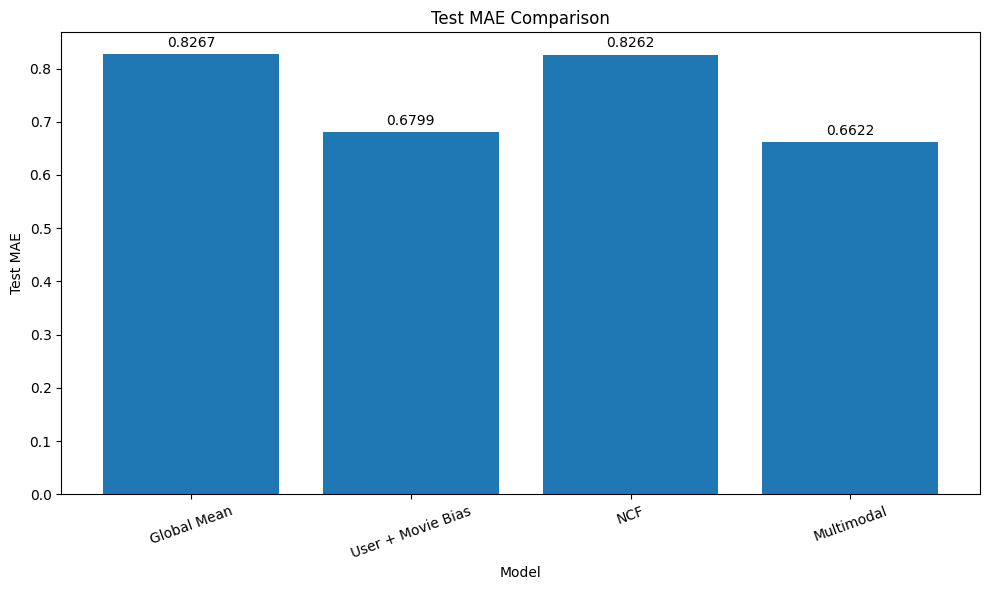

In [13]:
comparison_plot = final_results.copy()

overall_results = comparison_plot[
    comparison_plot["Evaluation"] == "Overall"
].copy()

plt.figure(figsize=(10, 6))

bars = plt.bar(
    overall_results["Model"],
    overall_results["Test MAE"]
)

# Add value labels on top of each bar
plt.bar_label(
    bars,
    fmt="%.4f",
    padding=3
)

plt.ylabel("Test MAE")
plt.xlabel("Model")
plt.title("Test MAE Comparison")
plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

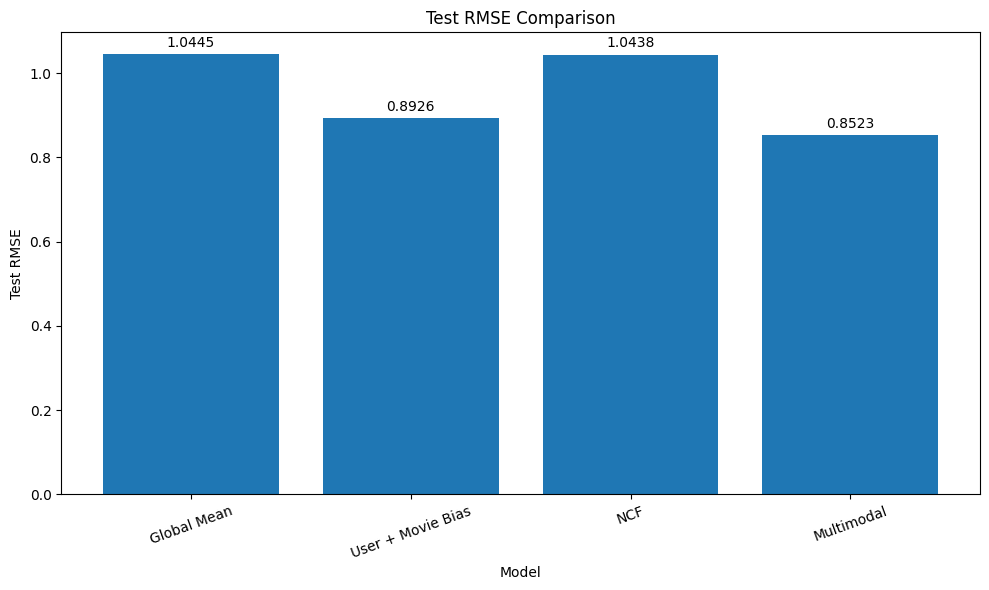

In [14]:
plt.figure(figsize=(10, 6))

bars = plt.bar(
    overall_results["Model"],
    overall_results["Test RMSE"]
)

# Add value labels on top of each bar
plt.bar_label(
    bars,
    fmt="%.4f",
    padding=3
)

plt.ylabel("Test RMSE")
plt.xlabel("Model")
plt.title("Test RMSE Comparison")

plt.xticks(rotation=20)

plt.tight_layout()
plt.show()

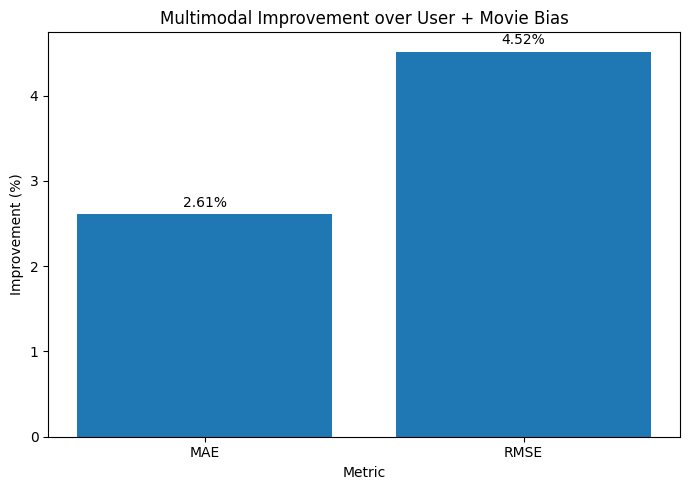

In [16]:
improvement_df = pd.DataFrame({
    "Metric": ["MAE", "RMSE"],
    "Improvement (%)": [
        mm_mae_improvement,
        mm_rmse_improvement
    ]
})

plt.figure(figsize=(7, 5))

bars = plt.bar(
    improvement_df["Metric"],
    improvement_df["Improvement (%)"]
)

# Add percentage labels
plt.bar_label(
    bars,
    fmt="%.2f%%",
    padding=3
)

plt.ylabel("Improvement (%)")
plt.xlabel("Metric")
plt.title("Multimodal Improvement over User + Movie Bias")

plt.tight_layout()
plt.show()

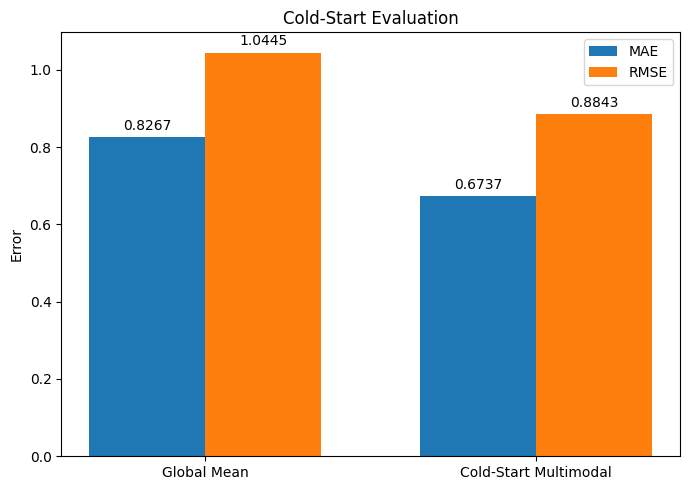

In [ ]:
coldstart_comparison = pd.DataFrame({
    "Model": [
        "Global Mean",
        "Cold-Start Multimodal"
    ],
    "MAE": [
        coldstart_global_mae,
        coldstart_mae
    ],
    "RMSE": [
        coldstart_global_rmse,
        coldstart_rmse
    ]
})

plt.figure(figsize=(7, 5))

x = np.arange(len(coldstart_comparison))
width = 0.35

# MAE bars
mae_bars = plt.bar(
    x - width / 2,
    coldstart_comparison["MAE"],
    width,
    label="MAE"
)

# RMSE bars
rmse_bars = plt.bar(
    x + width / 2,
    coldstart_comparison["RMSE"],
    width,
    label="RMSE"
)

# Add value labels
plt.bar_label(
    mae_bars,
    fmt="%.4f",
    padding=3
)

plt.bar_label(
    rmse_bars,
    fmt="%.4f",
    padding=3
)

plt.xticks(
    x,
    coldstart_comparison["Model"]
)

plt.ylabel("Error")
plt.title("Cold-Start Evaluation")
plt.legend()

plt.tight_layout()
plt.show()

## Step 10: Save Everything Required for Reload

In [19]:
recommendation_dir = "../../../recommendation_artifacts"

os.makedirs(
    recommendation_dir,
    exist_ok=True
)

print("Artifact directory:", recommendation_dir)

Artifact directory: ../../../recommendation_artifacts


In [20]:
multimodal_model.save(
    os.path.join(
        recommendation_dir,
        "multimodal_model.keras"
    )
)

coldstart_model.save(
    os.path.join(
        recommendation_dir,
        "coldstart_multimodal_model.keras"
    )

)

print("Models saved.")

NameError: name 'multimodal_model' is not defined

In [ ]:
with open(
    os.path.join(
        recommendation_dir,
        "user_to_index.pkl"
    ),
    "wb"
) as f:
    pickle.dump(user_to_index, f)

with open(
    os.path.join(
        recommendation_dir,
        "movie_to_index.pkl"
    ),
    "wb"
) as f:
    pickle.dump(movie_to_index, f)

with open(
    os.path.join(
        recommendation_dir,
        "multimodal_movie_index.pkl"
    ),
    "wb"
) as f:
    pickle.dump(multimodal_movie_index, f)

print("Mappings saved.")

In [21]:
np.save(
    os.path.join(
        recommendation_dir,
        "aligned_clip.npy"
    ),
    aligned_clip
)

np.save(
    os.path.join(
        recommendation_dir,
        "aligned_audio.npy"
    ),
    aligned_audio
)

np.save(
    os.path.join(
        recommendation_dir,
        "aligned_movie_ids.npy"
    ),
    np.array(
        aligned_movie_ids,
        dtype=np.int32
    )
)

print("Aligned embeddings saved.")

NameError: name 'aligned_clip' is not defined

In [ ]:
multimodal_movies.to_parquet(
    os.path.join(
        recommendation_dir,
        "multimodal_movies.parquet"
    ),
    index=False
)

print("Movie metadata saved.")

In [ ]:
artifact_config = {
    "num_users": int(num_users),
    "num_movies": int(num_movies),
    "clip_dim": 512,
    "audio_dim": 128,
    "embedding_dim": 32,
    "unk_movie_index": int(UNK_MOVIE_INDEX),
    "num_multimodal_movies": len(multimodal_movie_index)
}

with open(
    os.path.join(
        recommendation_dir,
        "config.json"
    ),
    "w"
) as f:
    json.dump(
        artifact_config,
        f,
        indent=4
    )

print(json.dumps(
    artifact_config,
    indent=4
))

In [ ]:
loaded_multimodal_model = keras.models.load_model(
    os.path.join(
        recommendation_dir,
        "multimodal_model.keras"
    )
)

loaded_coldstart_model = keras.models.load_model(
    os.path.join(
        recommendation_dir,
        "coldstart_multimodal_model.keras"
    )
)

with open(
    os.path.join(
        recommendation_dir,
        "user_to_index.pkl"
    ),
    "rb"
) as f:
    loaded_user_to_index = pickle.load(f)

with open(
    os.path.join(
        recommendation_dir,
        "movie_to_index.pkl"
    ),
    "rb"
) as f:
    loaded_movie_to_index = pickle.load(f)

with open(
    os.path.join(
        recommendation_dir,
        "multimodal_movie_index.pkl"
    ),
    "rb"
) as f:
    loaded_multimodal_movie_index = pickle.load(f)

loaded_clip = np.load(
    os.path.join(
        recommendation_dir,
        "aligned_clip.npy"
    )
)

loaded_audio = np.load(
    os.path.join(
        recommendation_dir,
        "aligned_audio.npy"
    )
)

loaded_movie_ids = np.load(
    os.path.join(
        recommendation_dir,
        "aligned_movie_ids.npy"
    )
)

loaded_movies = pd.read_parquet(
    os.path.join(
        recommendation_dir,
        "multimodal_movies.parquet"
    )
)

with open(
    os.path.join(
        recommendation_dir,
        "config.json"
    ),
    "r"
) as f:
    loaded_config = json.load(f)

print("Reload verification")
print("=" * 40)

print("Multimodal model:", loaded_multimodal_model is not None)
print("Cold-start model:", loaded_coldstart_model is not None)
print("Users:", len(loaded_user_to_index))
print("Movies:", len(loaded_movie_to_index))
print("Multimodal movies:", len(loaded_multimodal_movie_index))
print("CLIP:", loaded_clip.shape)
print("Audio:", loaded_audio.shape)
print("Movie IDs:", loaded_movie_ids.shape)
print("Movie metadata:", loaded_movies.shape)
print("Config:", loaded_config)

## Step 11: Recommendation System

In [113]:
# Create movie metadata lookup
movie_metadata = movies[["movieId", "title", "genres"]].drop_duplicates("movieId").copy()

movie_metadata.head()

NameError: name 'movies' is not defined